#   CLV  Churn Prediction System
**Customer Lifetime Value & Churn Analysis Pipeline**

---
| Component | Method |
|-----------|--------|
| Churn Prediction | XGBoost Classifier |
| CLV Estimation | XGBoost Regressor |
| Segmentation | KMeans Clustering |
| Dataset | Telco Customer Churn |



##  Step 1 - Install & Import Libraries

In [1]:
# Install required packages (Colab-compatible)
!pip install xgboost shap imbalanced-learn --quiet

import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ML — preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# ML — models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier, XGBRegressor

# ML — metrics
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_squared_error, r2_score, mean_absolute_error
)

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Class imbalance
from imblearn.over_sampling import SMOTE

# Explainability
import shap

# Style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
PALETTE = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']

print('All libraries loaded successfully!')

All libraries loaded successfully!


## Step 2 - Load Dataset

In [2]:
#  Load Telco Customer Churn dataset from GitHub
URL = ('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d'
       '/master/data/Telco-Customer-Churn.csv')

try:
    df = pd.read_csv(URL)
    print(f' Dataset loaded from GitHub  →  {df.shape[0]:,} rows × {df.shape[1]} cols')
except Exception:
    # Fallback: synthetic dataset so the notebook always runs
    print('  Network unavailable – generating synthetic Telco dataset …')
    np.random.seed(42)
    N = 7_043
    tenure      = np.random.randint(0, 73, N)
    monthly     = np.round(np.random.uniform(18, 120, N), 2)
    total       = np.round(monthly * tenure + np.random.normal(0, 50, N), 2)
    total       = np.clip(total, 0, None)
    churn_prob  = 1 / (1 + np.exp(-(0.05*(monthly-70) - 0.04*tenure + np.random.normal(0,.5,N))))
    churn       = (np.random.rand(N) < churn_prob).astype(int)

    df = pd.DataFrame({
        'customerID':        [f'ID-{i:05d}' for i in range(N)],
        'gender':            np.random.choice(['Male','Female'], N),
        'SeniorCitizen':     np.random.choice([0, 1], N, p=[0.84, 0.16]),
        'Partner':           np.random.choice(['Yes','No'], N),
        'Dependents':        np.random.choice(['Yes','No'], N),
        'tenure':            tenure,
        'PhoneService':      np.random.choice(['Yes','No'], N, p=[0.9, 0.1]),
        'MultipleLines':     np.random.choice(['Yes','No','No phone service'], N),
        'InternetService':   np.random.choice(['DSL','Fiber optic','No'], N),
        'OnlineSecurity':    np.random.choice(['Yes','No','No internet service'], N),
        'OnlineBackup':      np.random.choice(['Yes','No','No internet service'], N),
        'DeviceProtection':  np.random.choice(['Yes','No','No internet service'], N),
        'TechSupport':       np.random.choice(['Yes','No','No internet service'], N),
        'StreamingTV':       np.random.choice(['Yes','No','No internet service'], N),
        'StreamingMovies':   np.random.choice(['Yes','No','No internet service'], N),
        'Contract':          np.random.choice(['Month-to-month','One year','Two year'], N, p=[0.55,0.24,0.21]),
        'PaperlessBilling':  np.random.choice(['Yes','No'], N),
        'PaymentMethod':     np.random.choice(['Electronic check','Mailed check',
                                               'Bank transfer (automatic)',
                                               'Credit card (automatic)'], N),
        'MonthlyCharges':    monthly,
        'TotalCharges':      total.astype(str),   # intentional: mirrors real dataset
        'Churn':             np.where(churn==1,'Yes','No'),
    })
    print(f'Synthetic dataset ready  →  {df.shape[0]:,} rows × {df.shape[1]} cols')

print('\n── First 5 rows ──')
df.head()

 Dataset loaded from GitHub  →  7,043 rows × 21 cols

── First 5 rows ──


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##  Step 3 - Exploratory Data Analysis

In [3]:
print('━'*60)
print('DATASET OVERVIEW')
print('━'*60)
print(f'Shape          : {df.shape}')
print(f'Duplicates     : {df.duplicated().sum()}')
print(f'Missing values :\n{df.isnull().sum()[df.isnull().sum()>0]}')
print('\n── Dtypes ──')
print(df.dtypes.value_counts())
print('\n── Churn Distribution ──')
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Shape          : (7043, 21)
Duplicates     : 0
Missing values :
Series([], dtype: int64)

── Dtypes ──
object     18
int64       2
float64     1
Name: count, dtype: int64

── Churn Distribution ──
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


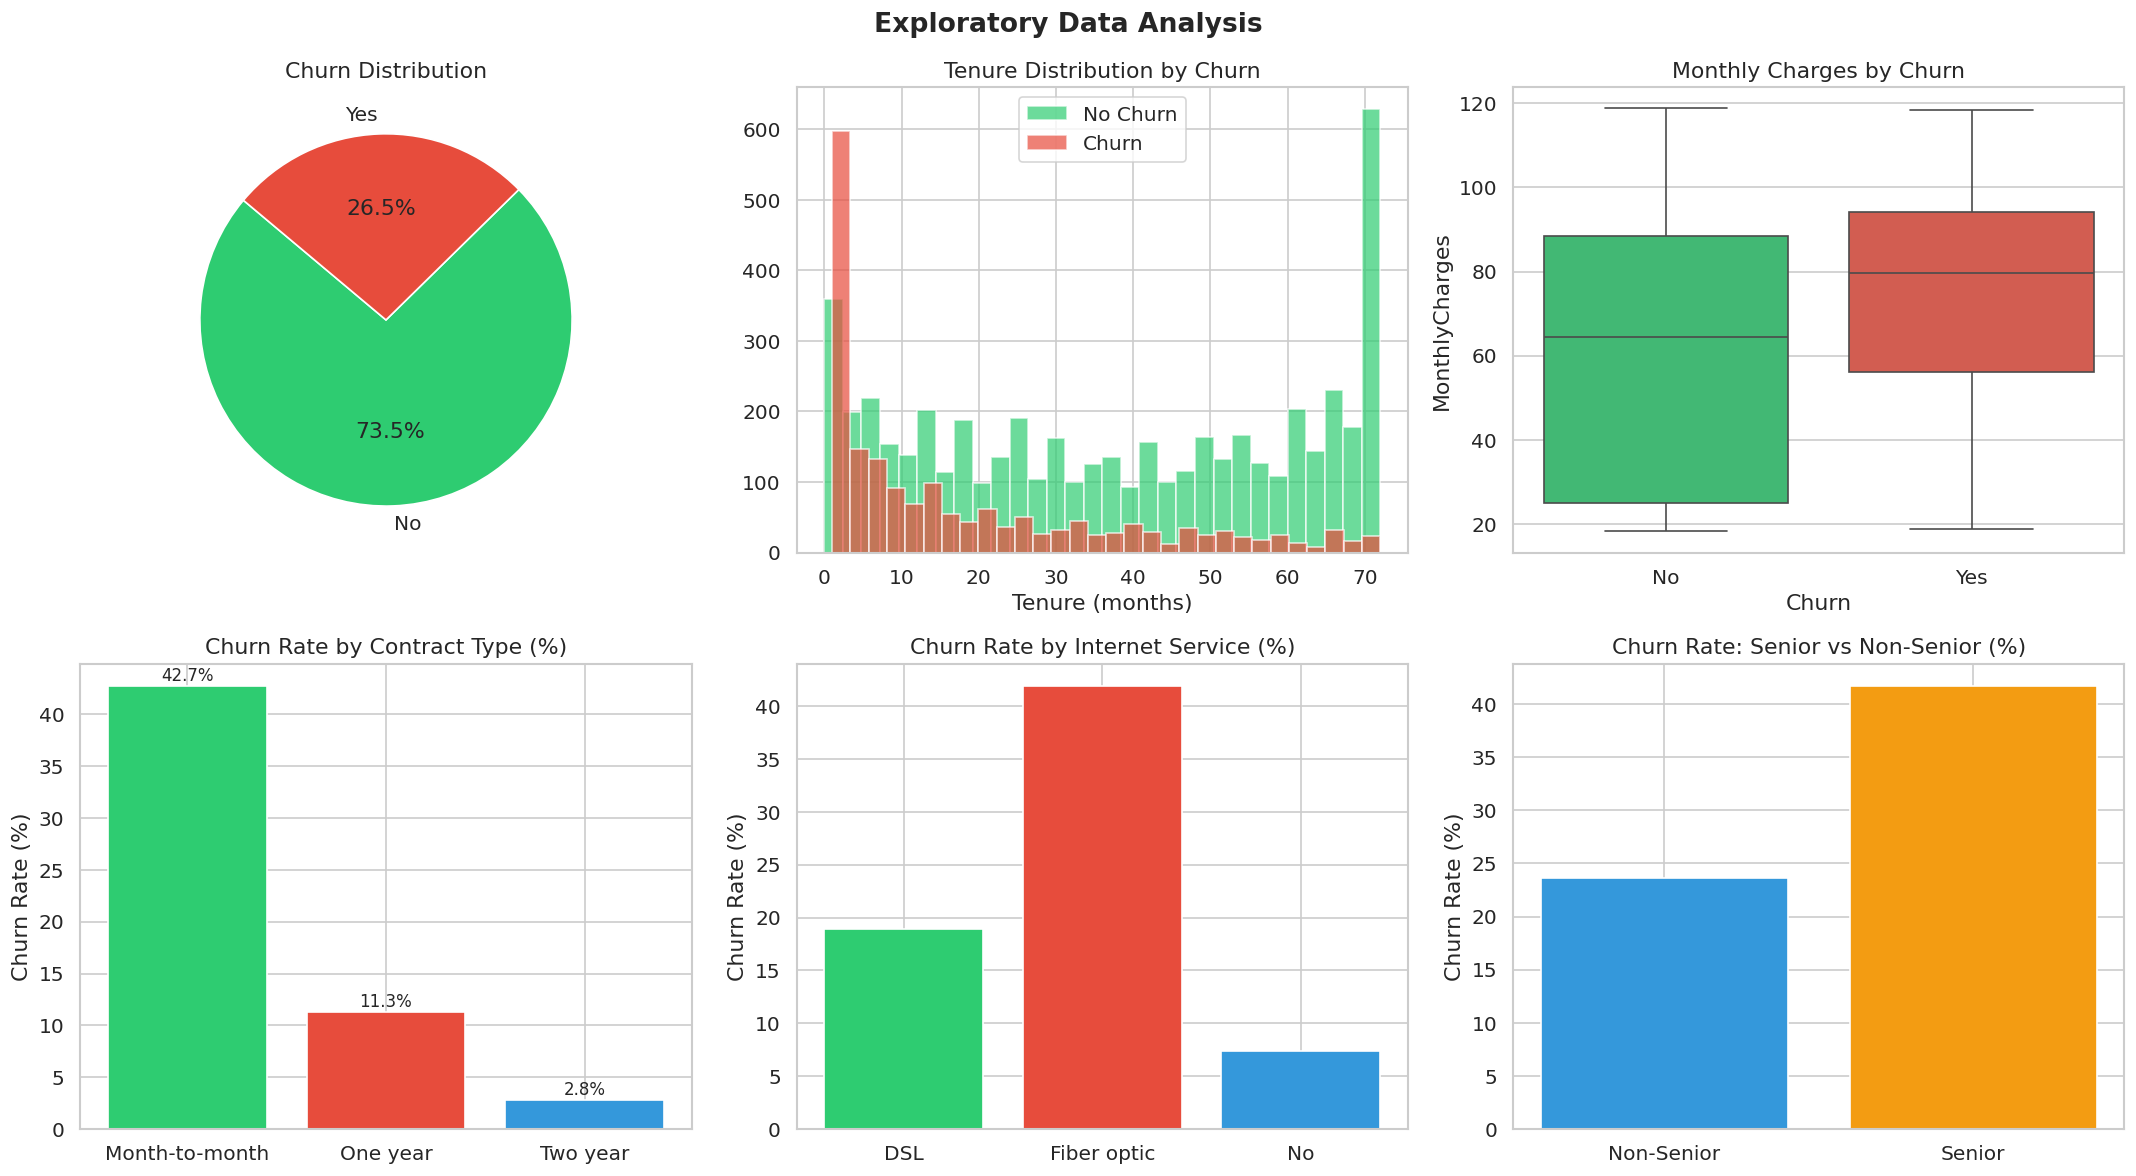

 EDA plots saved.


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Churn distribution
churn_counts = df['Churn'].value_counts()
axes[0,0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
              colors=[PALETTE[0], PALETTE[1]], startangle=140)
axes[0,0].set_title('Churn Distribution')

# Tenure distribution by churn
for label, col in zip(['No Churn','Churn'], [PALETTE[0], PALETTE[1]]):
    subset = df[df['Churn']==label[:2].replace('No','No').replace('Ch','Ye')]
axes[0,1].hist(df[df['Churn']=='No']['tenure'], bins=30, alpha=0.7,
               color=PALETTE[0], label='No Churn', edgecolor='white')
axes[0,1].hist(df[df['Churn']=='Yes']['tenure'], bins=30, alpha=0.7,
               color=PALETTE[1], label='Churn', edgecolor='white')
axes[0,1].set_title('Tenure Distribution by Churn')
axes[0,1].set_xlabel('Tenure (months)')
axes[0,1].legend()

# Monthly charges by churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[0,2],
            palette={'Yes': PALETTE[1], 'No': PALETTE[0]})
axes[0,2].set_title('Monthly Charges by Churn')

# Contract type vs churn
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)
bars = axes[1,0].bar(contract_churn.index, contract_churn.values,
                     color=PALETTE[:3], edgecolor='white')
axes[1,0].set_title('Churn Rate by Contract Type (%)')
axes[1,0].set_ylabel('Churn Rate (%)')
for bar, val in zip(bars, contract_churn.values):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{val:.1f}%', ha='center', fontsize=10)

# Internet service vs churn rate
isp_churn = df.groupby('InternetService')['Churn'].apply(
    lambda x: (x=='Yes').mean()*100)
axes[1,1].bar(isp_churn.index, isp_churn.values,
              color=PALETTE[:3], edgecolor='white')
axes[1,1].set_title('Churn Rate by Internet Service (%)')
axes[1,1].set_ylabel('Churn Rate (%)')

# Senior citizen churn
senior_churn = df.groupby('SeniorCitizen')['Churn'].apply(
    lambda x: (x=='Yes').mean()*100)
axes[1,2].bar(['Non-Senior','Senior'], senior_churn.values,
              color=[PALETTE[2], PALETTE[3]], edgecolor='white')
axes[1,2].set_title('Churn Rate: Senior vs Non-Senior (%)')
axes[1,2].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('eda_plots.png', bbox_inches='tight')
plt.show()
print(' EDA plots saved.')

##  Step 4 - Data Cleaning & Preprocessing

In [5]:
#  4.1  Copy & drop ID column
df_clean = df.copy()
df_clean.drop(columns=['customerID'], inplace=True, errors='ignore')

# 4.2  Fix TotalCharges (stored as string in the raw dataset)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
# Fill NaN TotalCharges with MonthlyCharges × tenure (logical imputation)
mask = df_clean['TotalCharges'].isna()
df_clean.loc[mask, 'TotalCharges'] = (
    df_clean.loc[mask, 'MonthlyCharges'] * df_clean.loc[mask, 'tenure']
)
print(f'TotalCharges NaN after imputation: {df_clean["TotalCharges"].isna().sum()}')

# 4.3  Binary-encode Yes/No columns
yes_no_cols = [
    'Partner','Dependents','PhoneService','PaperlessBilling',
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies','MultipleLines'
]
for col in yes_no_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map({'Yes':1,'No':0}).fillna(0).astype(int)

# 4.4  Encode target
df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)
df_clean['gender'] = (df_clean['gender'] == 'Male').astype(int)

# 4.5  One-hot encode remaining categoricals
ohe_cols = ['InternetService','Contract','PaymentMethod']
df_clean = pd.get_dummies(df_clean, columns=ohe_cols, drop_first=True)

print(f'\n Cleaned dataset shape: {df_clean.shape}')
print(f'Numeric columns: {df_clean.select_dtypes(include=np.number).shape[1]}')
print(f'\nChurn balance: {df_clean["Churn"].value_counts().to_dict()}')
df_clean.head(3)

TotalCharges NaN after imputation: 0

 Cleaned dataset shape: (7043, 24)
Numeric columns: 17

Churn balance: {0: 5174, 1: 1869}


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True


##  Step 5 - Feature Engineering

In [6]:
# 5.1  Derived features
df_fe = df_clean.copy()

# Revenue-related
df_fe['avg_monthly_spend']      = np.where(
    df_fe['tenure'] > 0,
    df_fe['TotalCharges'] / df_fe['tenure'],
    df_fe['MonthlyCharges']
)
df_fe['charges_delta']          = df_fe['MonthlyCharges'] - df_fe['avg_monthly_spend']
df_fe['revenue_per_service']    = df_fe['MonthlyCharges'] / (
    df_fe[['PhoneService','OnlineSecurity','OnlineBackup',
           'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']].sum(axis=1) + 1
)

# Engagement / loyalty
df_fe['tenure_group'] = pd.cut(df_fe['tenure'],
                                bins=[-1,12,24,48,73],
                                labels=[0,1,2,3]).astype(int)
df_fe['is_new_customer']        = (df_fe['tenure'] <= 6).astype(int)
df_fe['is_long_term']           = (df_fe['tenure'] >= 48).astype(int)

# Service adoption score (0-7)
svc_cols = ['PhoneService','OnlineSecurity','OnlineBackup',
            'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
df_fe['service_adoption_score'] = df_fe[svc_cols].sum(axis=1)

# Churn risk proxy (higher score → higher risk)
df_fe['churn_risk_proxy']       = (
    df_fe['MonthlyCharges'] / (df_fe['tenure'] + 1)
)

print(f' Features after engineering: {df_fe.shape[1]}')
print('New features added:')
new_feats = ['avg_monthly_spend','charges_delta','revenue_per_service',
             'tenure_group','is_new_customer','is_long_term',
             'service_adoption_score','churn_risk_proxy']
for f in new_feats:
    print(f'  • {f}: mean={df_fe[f].mean():.2f}, std={df_fe[f].std():.2f}')

 Features after engineering: 32
New features added:
  • avg_monthly_spend: mean=64.76, std=30.19
  • charges_delta: mean=-0.00, std=2.61
  • revenue_per_service: mean=17.08, std=6.93
  • tenure_group: mean=1.55, std=1.23
  • is_new_customer: mean=0.21, std=0.41
  • is_long_term: mean=0.33, std=0.47
  • service_adoption_score: mean=2.94, std=1.84
  • churn_risk_proxy: mean=5.77, std=8.72


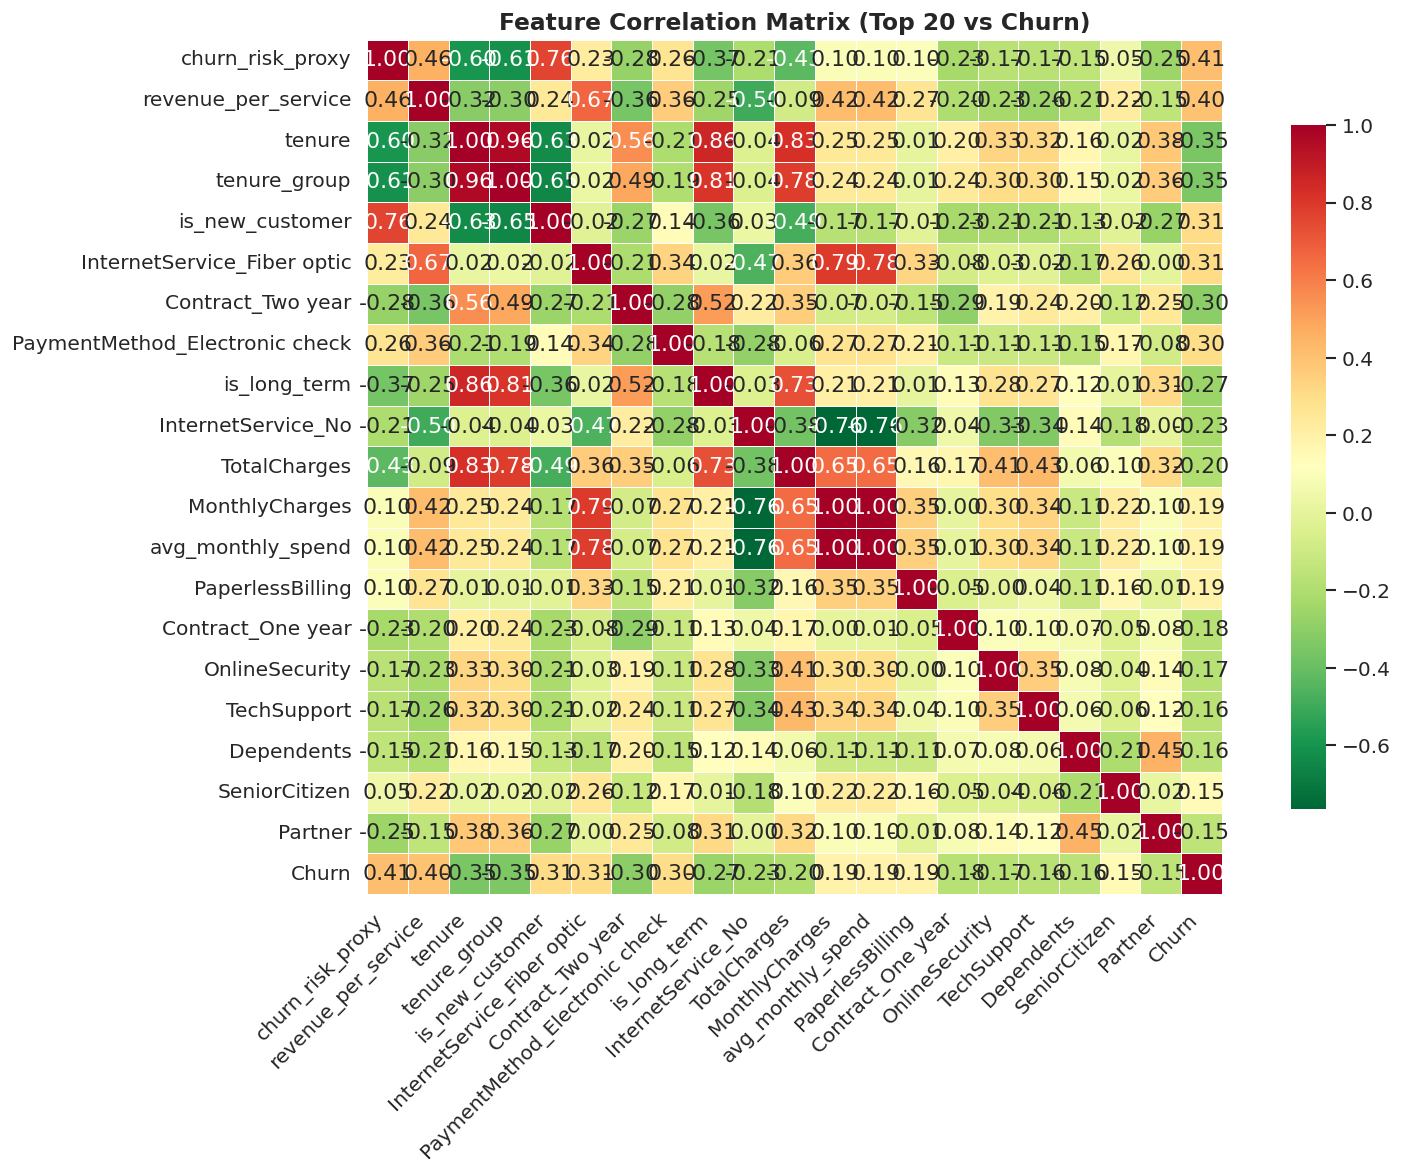

In [7]:
# Correlation heatmap - top-20 features vs Churn
corr_with_churn = df_fe.corr()['Churn'].drop('Churn').abs().nlargest(20)
top_cols = corr_with_churn.index.tolist() + ['Churn']

plt.figure(figsize=(14, 10))
sns.heatmap(df_fe[top_cols].corr(), annot=True, fmt='.2f',
            cmap='RdYlGn_r', linewidths=0.4, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix (Top 20 vs Churn)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

##  Step 6 - Churn Prediction (Classification)

In [8]:
# 6.1  Train / Test split
TARGET = 'Churn'
FEATURE_COLS = [c for c in df_fe.columns if c != TARGET]

X = df_fe[FEATURE_COLS].astype(float)
y = df_fe[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Churn rate – Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}')

#  6.2  SMOTE for class imbalance
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f'\nAfter SMOTE – Train: {X_train_res.shape}')
print(f'Churn balance: {pd.Series(y_train_res).value_counts().to_dict()}')

Train: (5634, 31) | Test: (1409, 31)
Churn rate – Train: 0.265 | Test: 0.265

After SMOTE – Train: (8278, 31)
Churn balance: {0: 4139, 1: 4139}


In [9]:
#  6.3  XGBoost Churn Model
xgb_churn = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_churn.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)],
    verbose=False
)

#  6.4  Predict & evaluate
y_pred_churn  = xgb_churn.predict(X_test)
y_prob_churn  = xgb_churn.predict_proba(X_test)[:, 1]

acc   = accuracy_score(y_test, y_pred_churn)
f1    = f1_score(y_test, y_pred_churn)
auc   = roc_auc_score(y_test, y_prob_churn)

print('━'*50)
print('CHURN MODEL — EVALUATION RESULTS')
print('━'*50)
print(f'  Accuracy  : {acc:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {auc:.4f}')
print('━'*50)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_churn, target_names=['No Churn','Churn']))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CHURN MODEL — EVALUATION RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy  : 0.7807
  F1-Score  : 0.5617
  ROC-AUC   : 0.8287
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.87      0.85      1035
       Churn       0.60      0.53      0.56       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.77      0.78      0.78      1409



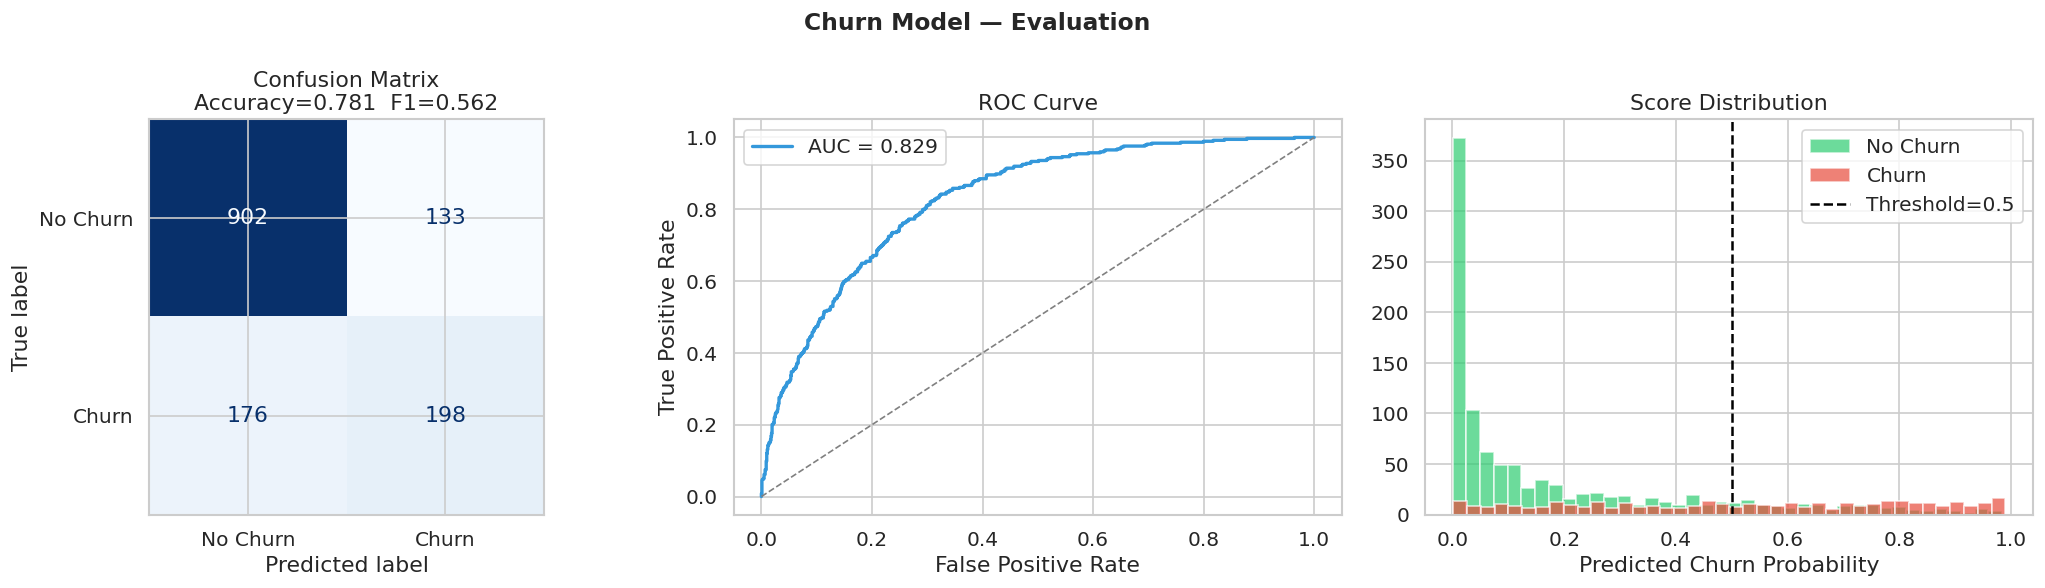

In [10]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Churn Model — Evaluation', fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_churn)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix\nAccuracy={acc:.3f}  F1={f1:.3f}')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_churn)
axes[1].plot(fpr, tpr, color=PALETTE[2], lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1],'--', color='grey', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Churn probability distribution
axes[2].hist(y_prob_churn[y_test==0], bins=40, alpha=0.7,
             color=PALETTE[0], label='No Churn', edgecolor='white')
axes[2].hist(y_prob_churn[y_test==1], bins=40, alpha=0.7,
             color=PALETTE[1], label='Churn', edgecolor='white')
axes[2].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold=0.5')
axes[2].set_xlabel('Predicted Churn Probability')
axes[2].set_title('Score Distribution')
axes[2].legend()

plt.tight_layout()
plt.savefig('churn_evaluation.png', bbox_inches='tight')
plt.show()

##  Step 7 - Customer Lifetime Value (CLV) Prediction

CLV distribution:
count    7043.00
mean     3719.85
std      1922.77
min       892.20
25%      1948.30
50%      3774.36
75%      5130.20
max      8684.80
Name: CLV, dtype: float64


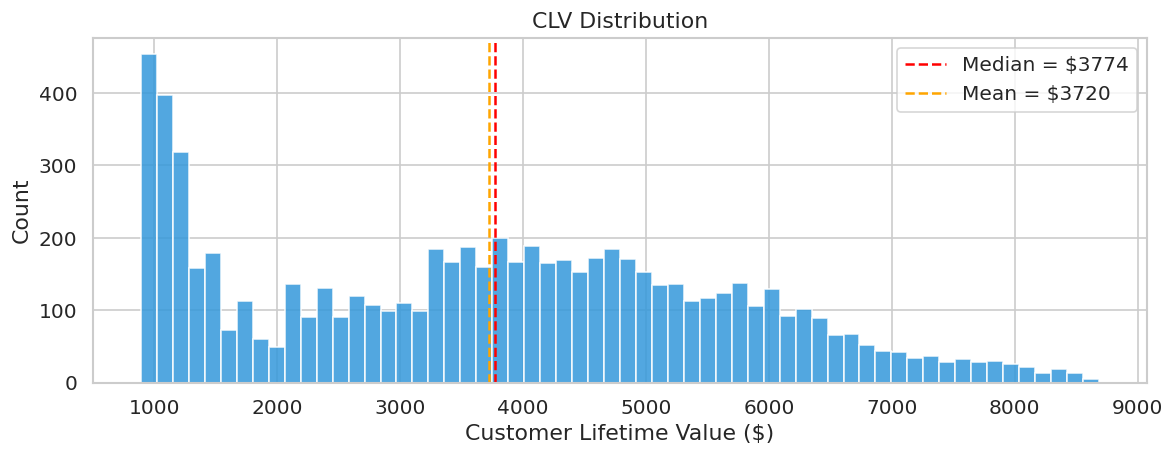

In [11]:
#  7.1  Construct CLV target variable
# Simplified CLV formula:
#   CLV = TotalCharges_to_date + (MonthlyCharges × expected_remaining_months)
#   expected_remaining_months = median_tenure(60) − current_tenure  [capped at 0]

MEDIAN_TENURE = 60    # assumed customer lifecycle
DISCOUNT_RATE = 0.10  # 10% annual discount → monthly ≈ 0.83%
r_monthly = DISCOUNT_RATE / 12

df_fe['expected_months_left'] = np.maximum(MEDIAN_TENURE - df_fe['tenure'], 0)

# Present value of future cash flows
# PV = MRR × [1 - (1+r)^{-n}] / r
n = df_fe['expected_months_left']
mrr = df_fe['MonthlyCharges']
pv_future = np.where(
    n > 0,
    mrr * (1 - (1 + r_monthly)**(-n)) / r_monthly,
    0
)

df_fe['CLV'] = df_fe['TotalCharges'] + pv_future

print('CLV distribution:')
print(df_fe['CLV'].describe().round(2))

plt.figure(figsize=(10, 4))
plt.hist(df_fe['CLV'], bins=60, color=PALETTE[2], edgecolor='white', alpha=0.85)
plt.axvline(df_fe['CLV'].median(), color='red', linestyle='--', label=f'Median = ${df_fe["CLV"].median():.0f}')
plt.axvline(df_fe['CLV'].mean(), color='orange', linestyle='--', label=f'Mean = ${df_fe["CLV"].mean():.0f}')
plt.xlabel('Customer Lifetime Value ($)')
plt.ylabel('Count')
plt.title('CLV Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('clv_distribution.png', bbox_inches='tight')
plt.show()

In [12]:
#  7.2  Train CLV Regression Model
CLV_TARGET = 'CLV'
clv_feature_cols = [c for c in df_fe.columns if c not in [CLV_TARGET, 'Churn',
                                                            'expected_months_left']]

Xc = df_fe[clv_feature_cols].astype(float)
yc = df_fe[CLV_TARGET]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42
)

xgb_clv = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb_clv.fit(
    Xc_train, yc_train,
    eval_set=[(Xc_test, yc_test)],
    verbose=False
)

# 7.3  Evaluate
yc_pred = xgb_clv.predict(Xc_test)

rmse = np.sqrt(mean_squared_error(yc_test, yc_pred))
mae  = mean_absolute_error(yc_test, yc_pred)
r2   = r2_score(yc_test, yc_pred)
mape = np.mean(np.abs((yc_test - yc_pred) / (yc_test + 1))) * 100

print('━'*50)
print('CLV MODEL — EVALUATION RESULTS')
print('━'*50)
print(f'  RMSE  : ${rmse:,.2f}')
print(f'  MAE   : ${mae:,.2f}')
print(f'  R²    : {r2:.4f}')
print(f'  MAPE  : {mape:.2f}%')
print('━'*50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CLV MODEL — EVALUATION RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RMSE  : $23.86
  MAE   : $16.12
  R²    : 0.9998
  MAPE  : 0.49%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


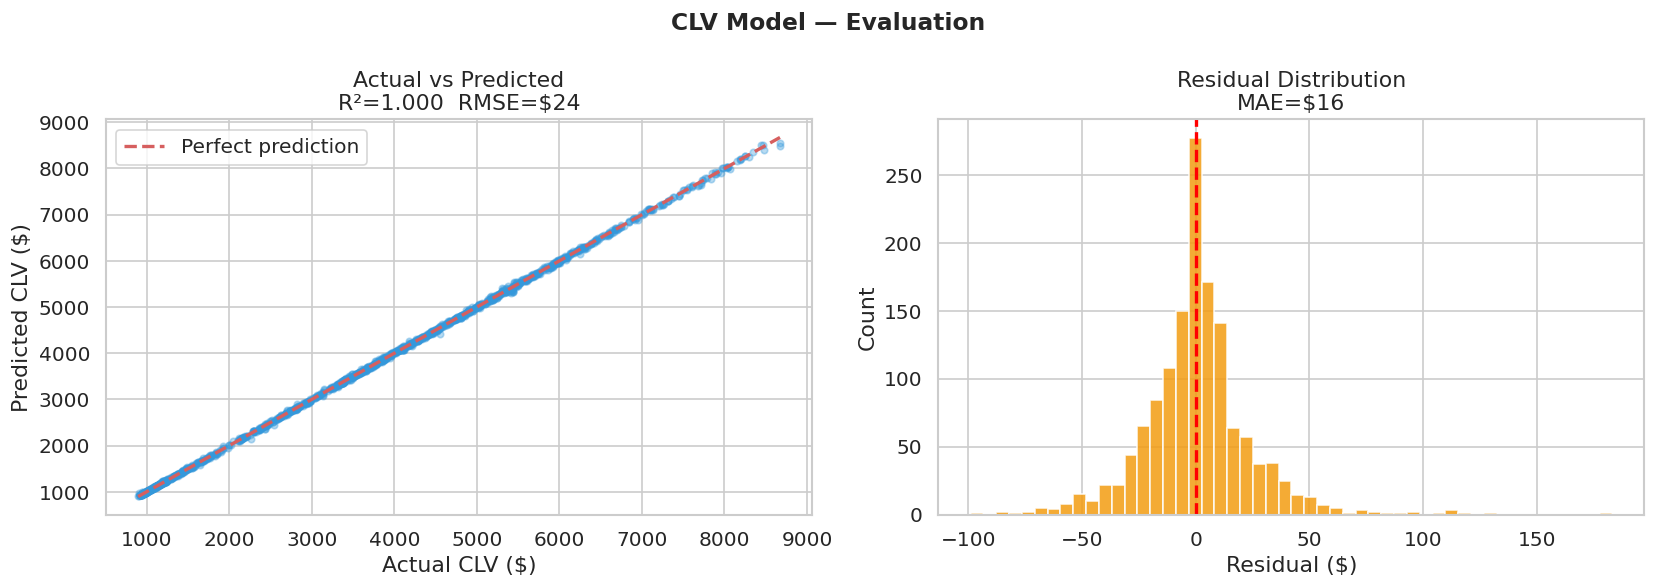

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CLV Model — Evaluation', fontsize=14, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(yc_test, yc_pred, alpha=0.35, color=PALETTE[2], s=15)
mn, mx = yc_test.min(), yc_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual CLV ($)')
axes[0].set_ylabel('Predicted CLV ($)')
axes[0].set_title(f'Actual vs Predicted\nR²={r2:.3f}  RMSE=${rmse:,.0f}')
axes[0].legend()

# Residuals
residuals = yc_test - yc_pred
axes[1].hist(residuals, bins=50, color=PALETTE[3], edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution\nMAE=${mae:,.0f}')

plt.tight_layout()
plt.savefig('clv_evaluation.png', bbox_inches='tight')
plt.show()

##  Step 8 - Feature Importance Analysis

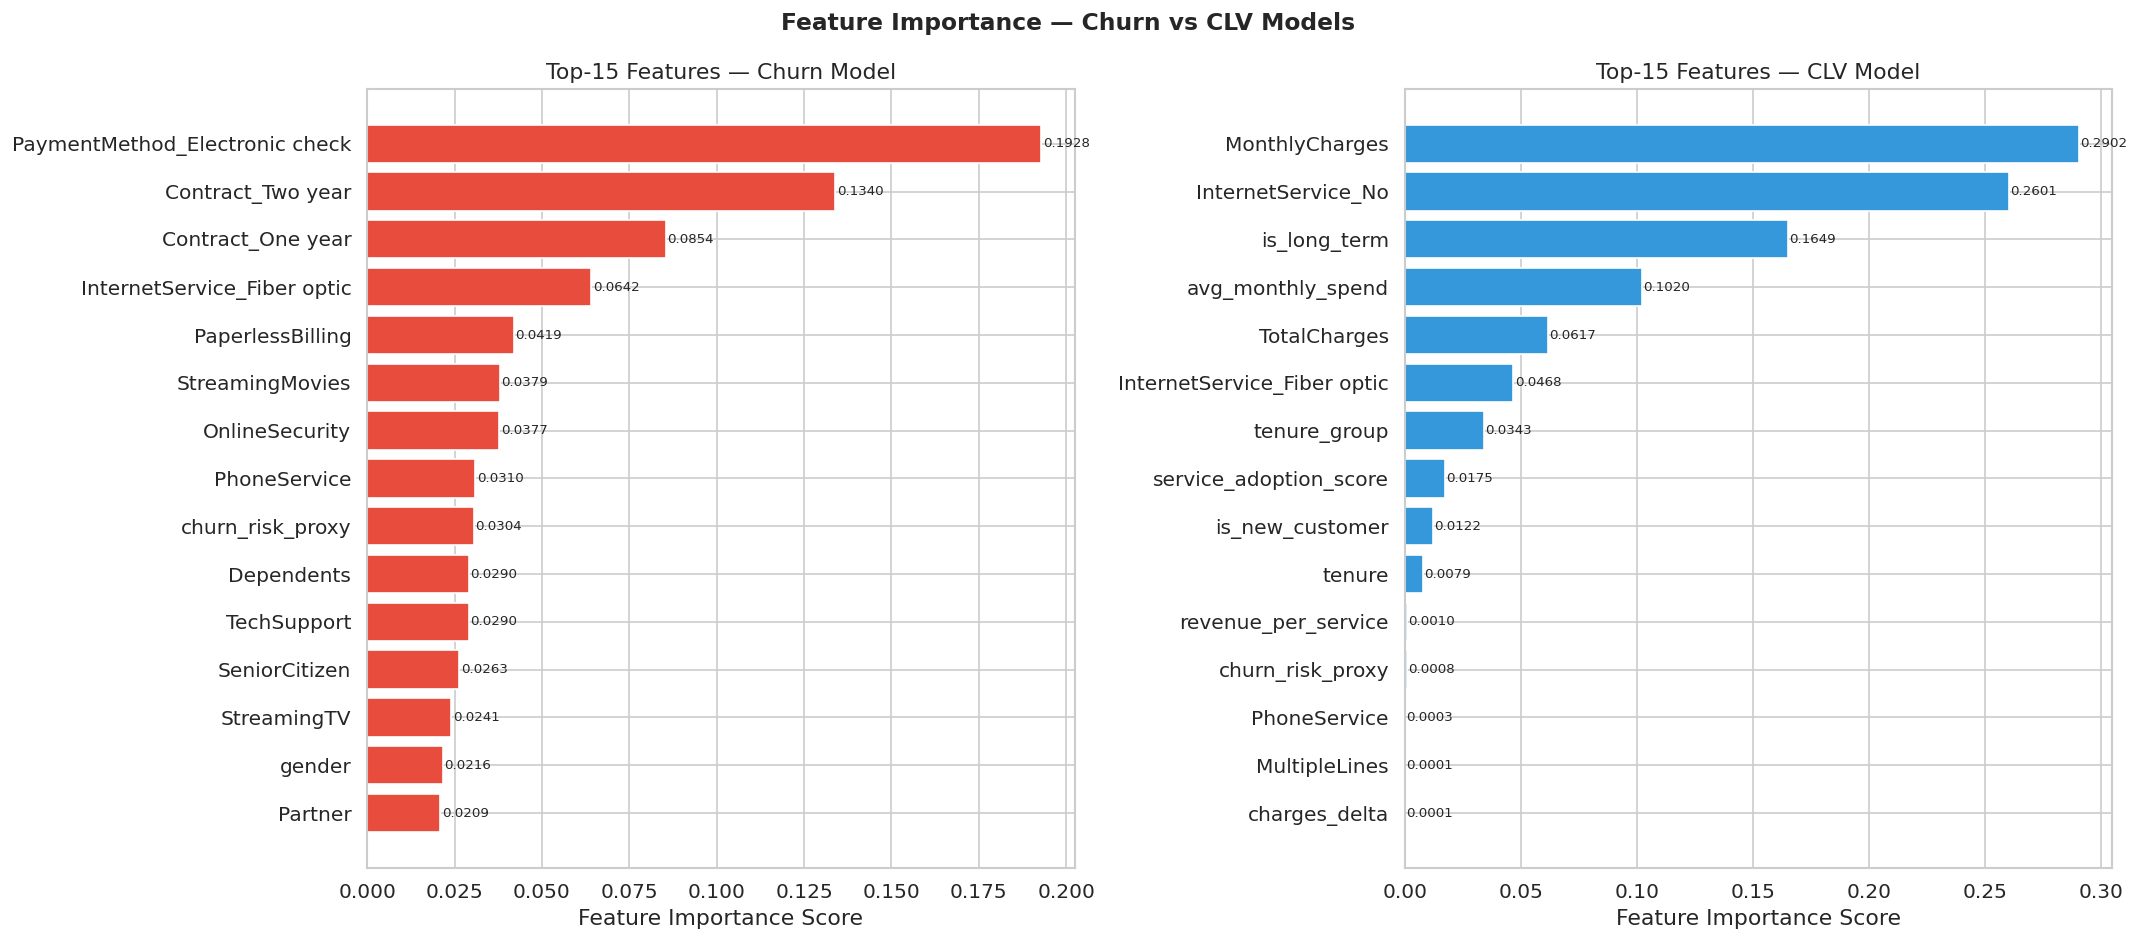

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Feature Importance — Churn vs CLV Models', fontsize=14, fontweight='bold')

def plot_importance(model, feature_names, ax, title, color):
    fi = pd.Series(model.feature_importances_, index=feature_names)
    fi = fi.nlargest(15).sort_values()
    bars = ax.barh(fi.index, fi.values, color=color, edgecolor='white')
    ax.set_xlabel('Feature Importance Score')
    ax.set_title(title)
    for bar, val in zip(bars, fi.values):
        ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

plot_importance(xgb_churn, FEATURE_COLS, axes[0],
                'Top-15 Features — Churn Model', PALETTE[1])
plot_importance(xgb_clv, clv_feature_cols, axes[1],
                'Top-15 Features — CLV Model', PALETTE[2])

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

Computing SHAP values (may take ~30 seconds) …


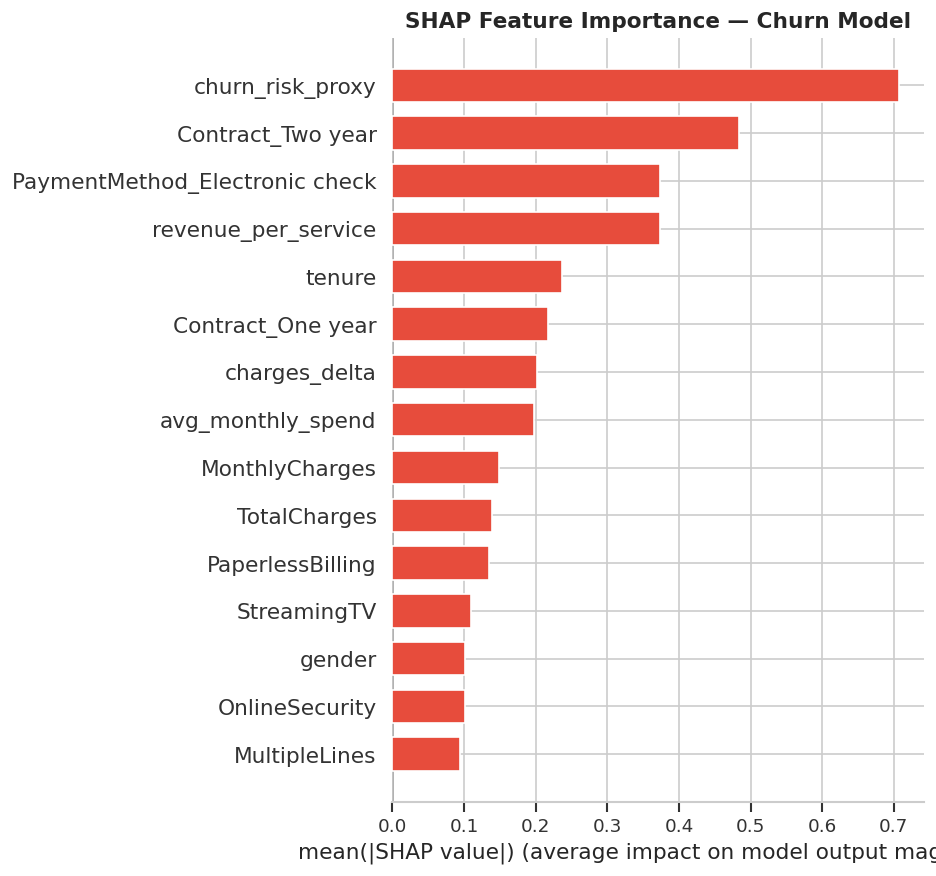

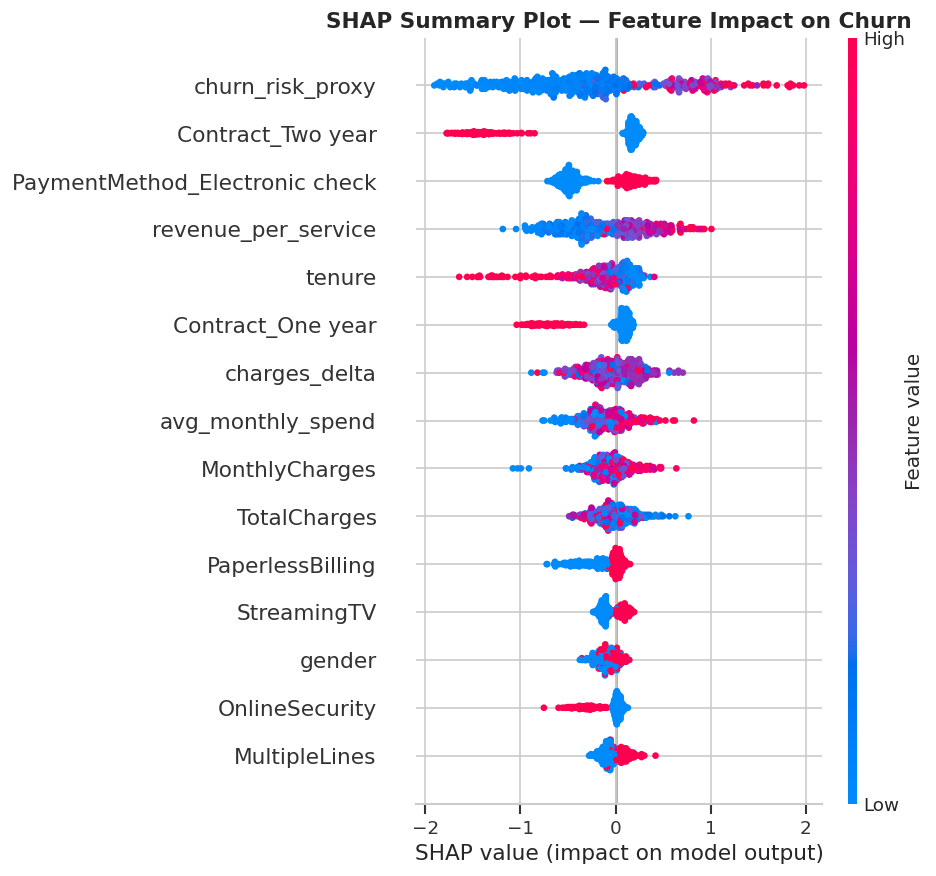

✅ SHAP analysis complete.


In [15]:
# SHAP Analysis for Churn Model
print('Computing SHAP values (may take ~30 seconds) …')

explainer_churn = shap.TreeExplainer(xgb_churn)

# Use a sample of 500 for speed
X_shap = X_test.sample(min(500, len(X_test)), random_state=42)
shap_values = explainer_churn.shap_values(X_shap)

plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False,
                  max_display=15, color=PALETTE[1])
plt.title('SHAP Feature Importance — Churn Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values, X_shap, show=False, max_display=15)
plt.title('SHAP Summary Plot — Feature Impact on Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()

print(' SHAP analysis complete.')

##   Step 9 - Customer Segmentation

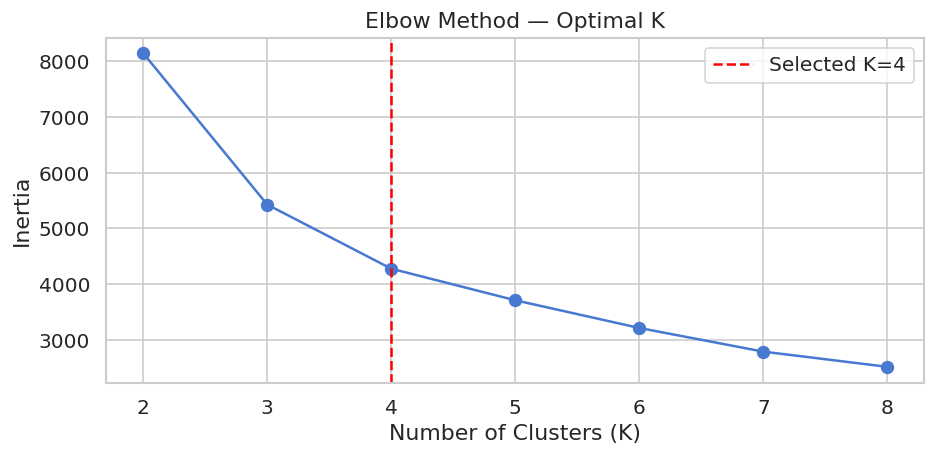

In [16]:
# 9.1  Attach model predictions to full dataset
df_fe['churn_probability'] = xgb_churn.predict_proba(X.astype(float))[:, 1]
df_fe['predicted_clv']     = xgb_clv.predict(Xc.astype(float))
df_fe['predicted_clv']     = np.clip(df_fe['predicted_clv'], 0, None)

#  9.2  Segmentation features
seg_features = ['tenure','MonthlyCharges','TotalCharges',
                'service_adoption_score','churn_probability','predicted_clv']

scaler_seg = RobustScaler()
X_seg = scaler_seg.fit_transform(df_fe[seg_features])

# Elbow method
inertia = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_seg)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-', markersize=7)
plt.axvline(4, color='red', linestyle='--', label='Selected K=4')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K')
plt.legend()
plt.tight_layout()
plt.savefig('elbow_plot.png', bbox_inches='tight')
plt.show()

In [24]:
#  9.3  Fit final K=4 segmentation
K = 4
km_final = KMeans(n_clusters=K, random_state=42, n_init='auto')
df_fe['segment'] = km_final.fit_predict(X_seg)

# Segment profile
seg_profile = df_fe.groupby('segment').agg(
    count=('segment','count'),
    avg_tenure=('tenure','mean'),
    avg_monthly_charges=('MonthlyCharges','mean'),
    avg_clv=('predicted_clv','mean'),
    avg_churn_prob=('churn_probability','mean'),
    avg_service_score=('service_adoption_score','mean'),
).round(2)

# Auto-label segments
def label_segment(row):
    if row['avg_churn_prob'] > 0.55 and row['avg_clv'] < seg_profile['avg_clv'].median():
        return ' High-Risk Low-Value'
    elif row['avg_churn_prob'] > 0.45 and row['avg_clv'] >= seg_profile['avg_clv'].median():
        return ' High-Risk High-Value'
    elif row['avg_churn_prob'] <= 0.30 and row['avg_clv'] >= seg_profile['avg_clv'].median():
        return ' Champions'
    else:
        return ' Loyal Mid-Value'

seg_profile['label'] = seg_profile.apply(label_segment, axis=1)

print('━'*70)
print('CUSTOMER SEGMENT PROFILES')
print('━'*70)
print(seg_profile.to_string())
print('━'*70)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CUSTOMER SEGMENT PROFILES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
         count  avg_tenure  avg_monthly_charges      avg_clv  avg_churn_prob  avg_service_score                 label
segment                                                                                                              
0         1727       34.96                71.66  4065.209961            0.14               3.57             Champions
1         1540       61.51                96.67  6273.629883            0.15               5.31             Champions
2         1659       10.18                76.26  3867.250000            0.72               2.38   High-Risk Low-Value
3         2117       26.45                26.92  1464.369995            0.12               1.14       Loyal Mid-Value
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


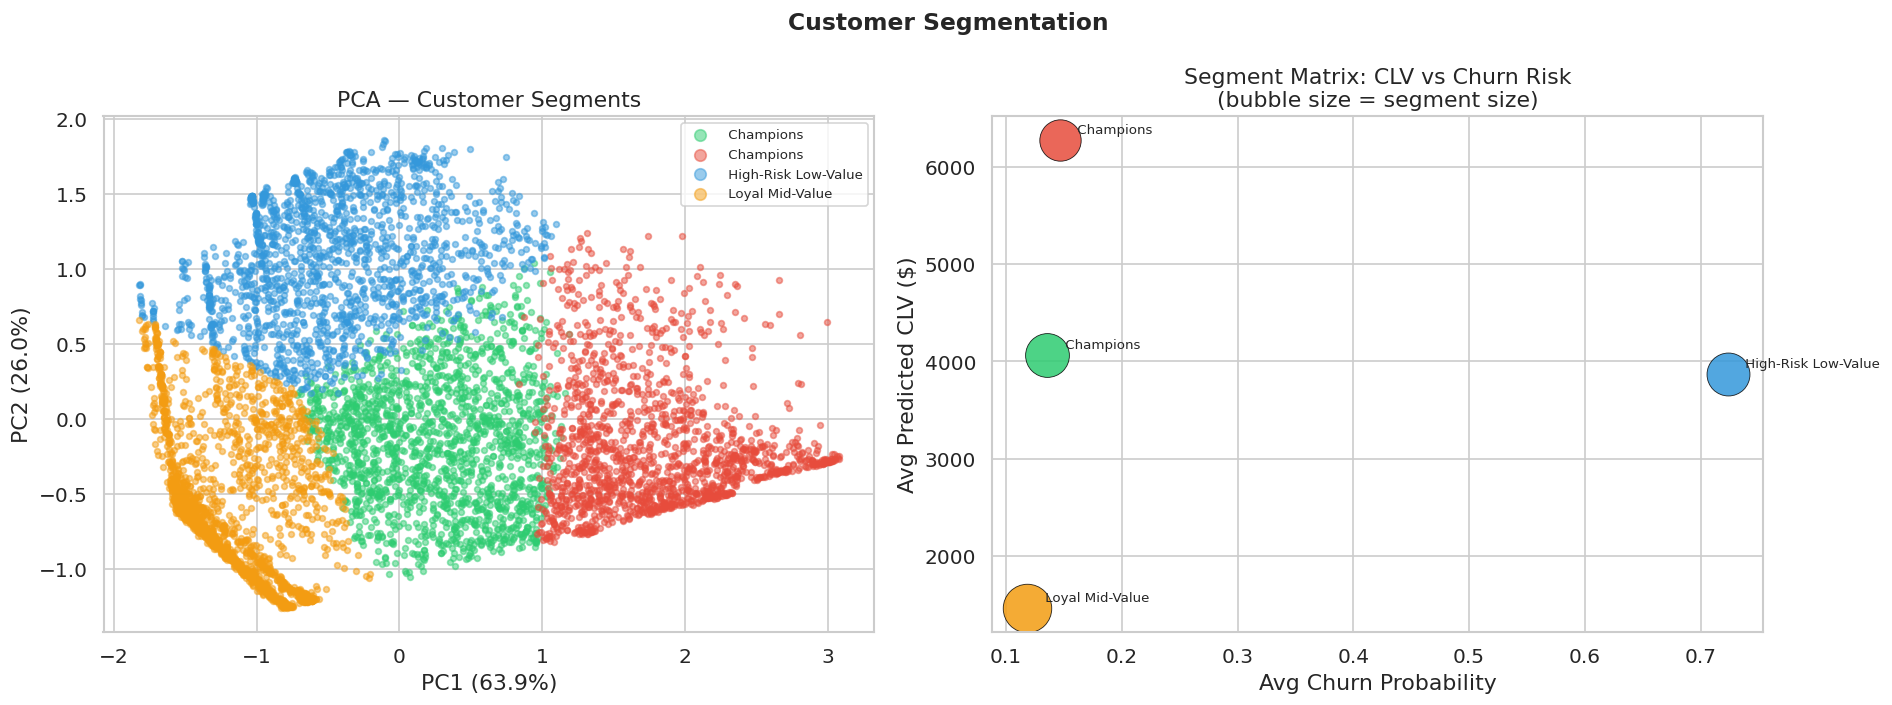

In [25]:
# PCA for 2D visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_seg)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Customer Segmentation', fontsize=14, fontweight='bold')

# PCA scatter
for seg_id, color in enumerate(PALETTE[:K]):
    mask = df_fe['segment'] == seg_id
    label = seg_profile.loc[seg_id, 'label'] if seg_id in seg_profile.index else str(seg_id)
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=label, alpha=0.5, s=12)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PCA — Customer Segments')
axes[0].legend(fontsize=8, markerscale=2)

# CLV vs Churn Probability bubble chart
seg_agg = df_fe.groupby('segment').agg(
    avg_churn=('churn_probability','mean'),
    avg_clv=('predicted_clv','mean'),
    count=('segment','count')
).reset_index()

for _, row in seg_agg.iterrows():
    seg_id = int(row['segment'])
    label  = seg_profile.loc[seg_id, 'label'] if seg_id in seg_profile.index else str(seg_id)
    axes[1].scatter(row['avg_churn'], row['avg_clv'],
                    s=row['count']*0.4, color=PALETTE[seg_id],
                    alpha=0.85, edgecolors='black', linewidth=0.5)
    axes[1].annotate(label, (row['avg_churn'], row['avg_clv']),
                     textcoords='offset points', xytext=(8, 4), fontsize=8)

axes[1].set_xlabel('Avg Churn Probability')
axes[1].set_ylabel('Avg Predicted CLV ($)')
axes[1].set_title('Segment Matrix: CLV vs Churn Risk\n(bubble size = segment size)')

plt.tight_layout()
plt.savefig('segmentation.png', bbox_inches='tight')
plt.show()

##  Step 10 - Business Recommendations & Retention Insights

In [26]:
#  10.1  Model-Driven Retention Score
# Retention Priority Score = CLV × Churn_Probability
# Highest scores = most revenue at risk → intervene first
df_fe['retention_priority_score'] = df_fe['predicted_clv'] * df_fe['churn_probability']

print('━'*65)
print('TOP-20 CUSTOMERS TO TARGET FOR RETENTION CAMPAIGNS')
print('━'*65)
top_20 = df_fe.nlargest(20, 'retention_priority_score')[
    ['tenure','MonthlyCharges','predicted_clv','churn_probability','retention_priority_score']
].reset_index(drop=True)
top_20.index += 1
print(top_20.to_string())
print(f'\n Total Revenue at Risk (Top 20): ${top_20["predicted_clv"].sum():,.0f}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TOP-20 CUSTOMERS TO TARGET FOR RETENTION CAMPAIGNS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    tenure  MonthlyCharges  predicted_clv  churn_probability  retention_priority_score
1       71          106.00    7742.689941           0.863415               6685.156738
2       69          106.50    7325.337891           0.895642               6560.877441
3       68          105.30    7303.519531           0.857053               6259.503906
4       69          103.95    7411.617188           0.842307               6242.859375
5       71          108.05    7530.720703           0.798456               6012.948242
6       66          110.85    7524.321777           0.768748               5784.303711
7       67          118.35    7791.239258           0.741541               5777.521484
8       68          108.45    7179.584961           0.796412               5717.908691
9       43          101.40    6133

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CHURN RISK TIER SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
           customers      avg_clv    total_clv  avg_churn_prob  pct_customers
risk_tier                                                                    
Critical        1093  3984.120117   4354638.00            0.84           15.5
High             694  3917.570068   2718794.50            0.60            9.9
Medium           631  3769.860107   2378782.75            0.40            9.0
Low             4625  3620.679932  16745638.00            0.07           65.7


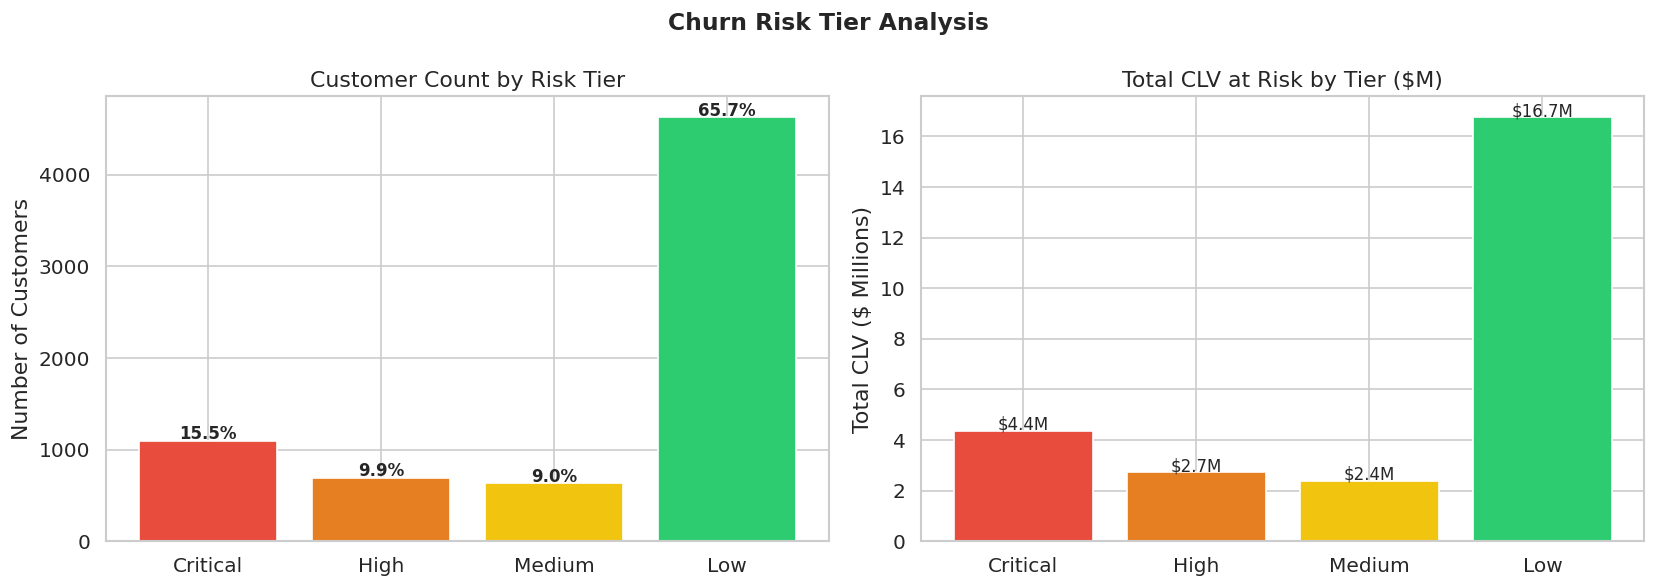

In [20]:
#  10.2  Risk Tier Assignment
def assign_risk_tier(prob):
    if prob >= 0.70:   return 'Critical'
    elif prob >= 0.50: return 'High'
    elif prob >= 0.30: return 'Medium'
    else:              return 'Low'

df_fe['risk_tier'] = df_fe['churn_probability'].apply(assign_risk_tier)

tier_summary = df_fe.groupby('risk_tier').agg(
    customers=('risk_tier','count'),
    avg_clv=('predicted_clv','mean'),
    total_clv=('predicted_clv','sum'),
    avg_churn_prob=('churn_probability','mean')
).round(2)
tier_summary['pct_customers'] = (tier_summary['customers'] / len(df_fe) * 100).round(1)
tier_summary = tier_summary.reindex(['Critical','High','Medium','Low'])

print('━'*65)
print('CHURN RISK TIER SUMMARY')
print('━'*65)
print(tier_summary.to_string())

# Plot risk tier revenue exposure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn Risk Tier Analysis', fontsize=14, fontweight='bold')

tier_colors = {'Critical': '#e74c3c', 'High': '#e67e22',
               'Medium': '#f1c40f', 'Low': '#2ecc71'}

tiers = tier_summary.index.tolist()
colors = [tier_colors[t] for t in tiers]

axes[0].bar(tiers, tier_summary['customers'], color=colors, edgecolor='white')
axes[0].set_title('Customer Count by Risk Tier')
axes[0].set_ylabel('Number of Customers')
for i, (t, row) in enumerate(tier_summary.iterrows()):
    axes[0].text(i, row['customers']+20, f'{row["pct_customers"]}%',
                 ha='center', fontsize=10, fontweight='bold')

axes[1].bar(tiers, tier_summary['total_clv']/1e6, color=colors, edgecolor='white')
axes[1].set_title('Total CLV at Risk by Tier ($M)')
axes[1].set_ylabel('Total CLV ($ Millions)')
for i, (t, row) in enumerate(tier_summary.iterrows()):
    axes[1].text(i, row['total_clv']/1e6+0.05,
                 f'${row["total_clv"]/1e6:.1f}M', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('risk_tiers.png', bbox_inches='tight')
plt.show()

In [27]:
# 10.3  Automated Business Recommendations

def generate_recommendations(seg_profile, tier_summary, df):
    recs = []

    # Critical churn tier
    critical = tier_summary.loc['Critical']
    recs.append({
        'Priority': ' P1 — Immediate Retention',
        'Insight': f'{critical["customers"]:.0f} customers ({critical["pct_customers"]}%) '
                   f'are at CRITICAL churn risk (>70% probability)',
        'Revenue_at_Risk': f'${critical["total_clv"]:,.0f}',
        'Action': 'Deploy personalised win-back offers within 48 hours. '
                  'Assign dedicated account managers for High-Value critical customers. '
                  'Offer contract upgrade incentives.'
    })

    # Month-to-month contract risk
    if 'Contract_One year' in df.columns:
        m2m_mask  = (df['Contract_One year']==0) & (df.get('Contract_Two year',pd.Series(0))==0)
        m2m_churn = df.loc[m2m_mask, 'churn_probability'].mean()
        recs.append({
            'Priority': ' P2 — Contract Upgrade Campaign',
            'Insight': f'Month-to-month customers avg churn probability: {m2m_churn:.1%}',
            'Revenue_at_Risk': f'${df.loc[m2m_mask,"predicted_clv"].sum():,.0f}',
            'Action': 'Offer 10-15% discount for switching to 1-year contracts. '
                      'Bundle free premium services (StreamingTV/Backup) for 2-year commits.'
        })

    # New customer early churn
    new_cust = df[df['is_new_customer']==1]
    new_churn_rate = new_cust['churn_probability'].mean()
    recs.append({
        'Priority': ' P3 — Early Lifecycle Programme',
        'Insight': f'New customers (≤6 months) avg churn probability: {new_churn_rate:.1%}. '
                   f'{len(new_cust):,} customers in this cohort.',
        'Revenue_at_Risk': f'${new_cust["predicted_clv"].sum():,.0f}',
        'Action': 'Implement 90-day onboarding journey with check-in calls at days 14, 45, 90. '
                  'Offer complimentary TechSupport/OnlineSecurity for first 3 months.'
    })

    # Champions upsell
    champions = df[df['risk_tier']=='Low']
    recs.append({
        'Priority': ' P4 — Champion Upsell',
        'Insight': f'{len(champions):,} low-risk customers with avg CLV ${champions["predicted_clv"].mean():.0f}.',
        'Revenue_at_Risk': 'Opportunity',
        'Action': 'Launch loyalty rewards programme. Offer referral bonuses. '
                  'Cross-sell premium add-ons (StreamingTV, DeviceProtection).'
    })

    return pd.DataFrame(recs)

recommendations = generate_recommendations(seg_profile, tier_summary, df_fe)

print('━'*80)
print('STRATEGIC BUSINESS RECOMMENDATIONS')
print('━'*80)
for _, row in recommendations.iterrows():
    print(f'\n{row["Priority"]}')
    print(f'  Insight          : {row["Insight"]}')
    print(f'  Revenue at Risk  : {row["Revenue_at_Risk"]}')
    print(f'  Recommended Action: {row["Action"]}')
    print('  ' + '─'*76)
print('━'*80)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
STRATEGIC BUSINESS RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 P1 — Immediate Retention
  Insight          : 1093 customers (15.5%) are at CRITICAL churn risk (>70% probability)
  Revenue at Risk  : $4,354,638
  Recommended Action: Deploy personalised win-back offers within 48 hours. Assign dedicated account managers for High-Value critical customers. Offer contract upgrade incentives.
  ────────────────────────────────────────────────────────────────────────────

 P2 — Contract Upgrade Campaign
  Insight          : Month-to-month customers avg churn probability: 43.9%
  Revenue at Risk  : $13,685,532
  Recommended Action: Offer 10-15% discount for switching to 1-year contracts. Bundle free premium services (StreamingTV/Backup) for 2-year commits.
  ────────────────────────────────────────────────────────────────────────────

 P3 — Early Lifecycle Prog

##  Step 11 - Final Dashboard Summary

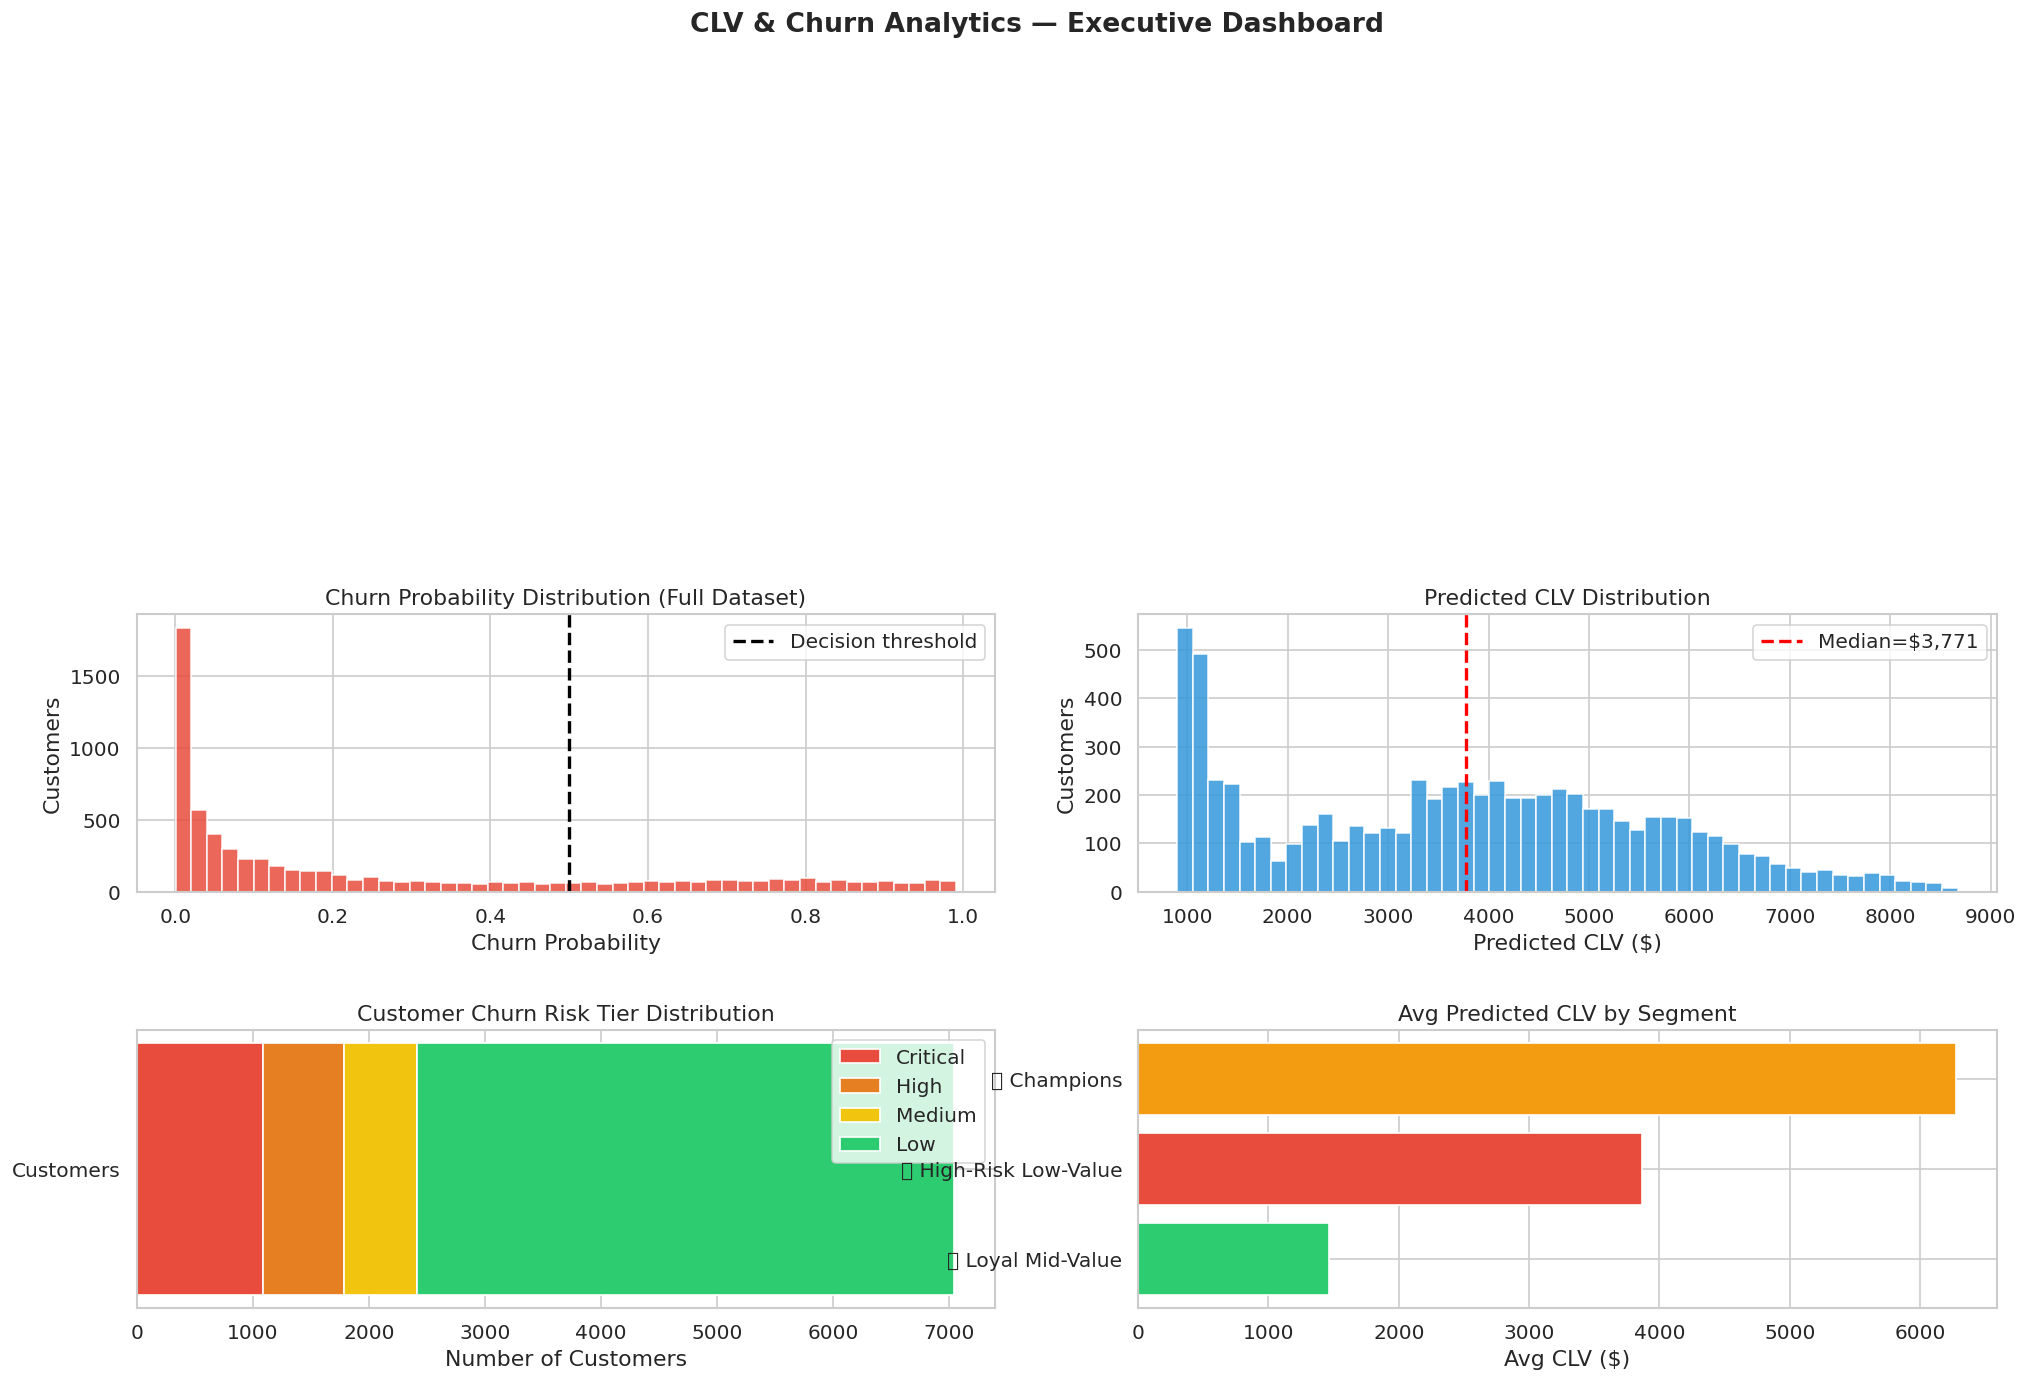

✅ Executive dashboard saved.


In [22]:
fig = plt.figure(figsize=(20, 12))
fig.suptitle('CLV & Churn Analytics — Executive Dashboard', fontsize=16,
             fontweight='bold', y=1.01)

gs = fig.add_gridspec(3, 4, hspace=0.5, wspace=0.4)

# KPI boxes
kpis = [
    ('Churn F1-Score',      f'{f1:.3f}',            PALETTE[0]),
    ('Churn ROC-AUC',       f'{auc:.3f}',            PALETTE[1]),
    ('CLV R²',              f'{r2:.3f}',             PALETTE[2]),
    ('CLV RMSE',            f'${rmse:,.0f}',         PALETTE[3]),
]

for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, value, ha='center', va='center',
            fontsize=22, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.2, label, ha='center', va='center',
            fontsize=10, color='white', transform=ax.transAxes)
    ax.axis('off')

#  Churn distribution
ax1 = fig.add_subplot(gs[1, :2])
ax1.hist(df_fe['churn_probability'], bins=50,
         color=PALETTE[1], edgecolor='white', alpha=0.85)
ax1.axvline(0.5, color='black', linestyle='--', lw=2, label='Decision threshold')
ax1.set_title('Churn Probability Distribution (Full Dataset)')
ax1.set_xlabel('Churn Probability')
ax1.set_ylabel('Customers')
ax1.legend()

# CLV distribution
ax2 = fig.add_subplot(gs[1, 2:])
ax2.hist(df_fe['predicted_clv'], bins=50,
         color=PALETTE[2], edgecolor='white', alpha=0.85)
ax2.axvline(df_fe['predicted_clv'].median(), color='red', linestyle='--',
            lw=2, label=f'Median=${df_fe["predicted_clv"].median():,.0f}')
ax2.set_title('Predicted CLV Distribution')
ax2.set_xlabel('Predicted CLV ($)')
ax2.set_ylabel('Customers')
ax2.legend()

#  Risk Tier stacked bar
ax3 = fig.add_subplot(gs[2, :2])
tier_order   = ['Critical','High','Medium','Low']
tier_colors_ = ['#e74c3c','#e67e22','#f1c40f','#2ecc71']
tier_vals    = [tier_summary.loc[t,'customers'] for t in tier_order]
ax3.barh(['Customers'], [tier_vals[0]], color=tier_colors_[0], label='Critical')
left = tier_vals[0]
for i in range(1, 4):
    ax3.barh(['Customers'], [tier_vals[i]], left=left,
             color=tier_colors_[i], label=tier_order[i])
    left += tier_vals[i]
ax3.set_title('Customer Churn Risk Tier Distribution')
ax3.set_xlabel('Number of Customers')
ax3.legend(loc='upper right')

#  Segment CLV bar
ax4 = fig.add_subplot(gs[2, 2:])
seg_clv = df_fe.groupby('segment')['predicted_clv'].mean().sort_values()
seg_labels = [seg_profile.loc[i,'label'] if i in seg_profile.index else str(i)
              for i in seg_clv.index]
ax4.barh(seg_labels, seg_clv.values,
         color=PALETTE[:len(seg_clv)], edgecolor='white')
ax4.set_title('Avg Predicted CLV by Segment')
ax4.set_xlabel('Avg CLV ($)')

plt.savefig('executive_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Executive dashboard saved.')

In [29]:
#  Export scored customer data
output_cols = [
    'tenure','MonthlyCharges','TotalCharges',
    'service_adoption_score','Churn',
    'churn_probability','predicted_clv',
    'retention_priority_score','risk_tier','segment'
]
df_output = df_fe[[c for c in output_cols if c in df_fe.columns]].copy()
df_output.to_csv('clv_churn_scored_customers.csv', index=False)

print('━'*60)
print(' PIPELINE COMPLETE')
print('━'*60)
print('\nFiles saved:')
print('  • clv_churn_scored_customers.csv')
print('  • executive_dashboard.png')
print('  • eda_plots.png')
print('  • churn_evaluation.png')
print('  • clv_evaluation.png')
print('  • feature_importance.png')
print('  • shap_importance.png / shap_summary.png')
print('  • segmentation.png')
print('  • risk_tiers.png')
print(f'\nModel Summary:')
print(f'  Churn Accuracy : {acc:.4f}')
print(f'  Churn F1       : {f1:.4f}')
print(f'  Churn AUC      : {auc:.4f}')
print(f'  CLV R²         : {r2:.4f}')
print(f'  CLV RMSE       : ${rmse:,.2f}')
print(f'\nBusiness Impact:')
print(f'  Total customers analysed  : {len(df_fe):,}')
print(f'  Critical-risk customers   : {tier_summary.loc["Critical","customers"]:.0f}')
print(f'  Total CLV at critical risk: ${tier_summary.loc["Critical","total_clv"]:,.0f}')
print(f'  Avg predicted CLV         : ${df_fe["predicted_clv"].mean():,.0f}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PIPELINE COMPLETE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Files saved:
  • clv_churn_scored_customers.csv
  • executive_dashboard.png
  • eda_plots.png
  • churn_evaluation.png
  • clv_evaluation.png
  • feature_importance.png
  • shap_importance.png / shap_summary.png
  • segmentation.png
  • risk_tiers.png

Model Summary:
  Churn Accuracy : 0.7807
  Churn F1       : 0.5617
  Churn AUC      : 0.8287
  CLV R²         : 0.9998
  CLV RMSE       : $23.86

Business Impact:
  Total customers analysed  : 7,043
  Critical-risk customers   : 1093
  Total CLV at critical risk: $4,354,638
  Avg predicted CLV         : $3,720
